# ECS8051 - Coursework 1 - Student 40466218 - Conor Brown

In [ ]:
### Notes on Running the Notebook
# The file student_experimentation.py file has to be in the same directory as the notebook for the imports to work.
# The saved notebook contains outputs for every cell.
# If the notebook is re-run, the heaviest sections - feature engineering, hyperparameter selection, and cross-validation at step=1 for the boosted models - have been commented out 
# to allow it to run within c. 30 minutes using the hardcoded results of feature and hyperparameter selection. 
# Key results are still present in the notebook in this reduced state.
# The lengthy training time is due to consistent use of the robust time-aware walk-forward validation methods in mltester.py to minimise data leakage risks.
# The cells can be uncommented out to run in 2 hours to see the full experimentation and replicate the results exactly, if required. 

## Summary

In this report we build a machine learning model to predict next-_H_-day cumulative log return $y_t = \log(C_{t+H}/C_t)$ for a broad cross-section of industry ETFs (XLE, XLF, XLI, XLK, XLP, XLV). 

The model training and evaluation process was:

- Train a Ridge regression model on raw OHLCV indicators to establish baseline performance.
- Train other linear and ensemble models - ElasticNet, Random Forest, XGBoost and LightGBM - to demonstrate the benefits of model selection.
- Engineer new features from the raw features to demonstrate the performance benefits of feature engineering, and the costs associated with the curse of dimensionality.
- Identify the best hyperparameters for the models using an extensive randomised search cross-validation.
- Measure feature importance and perform feature selection on the best model with optimised hyper-parameters.
- Evaluate the final model with the optimal feature set and hyperparameters using a walk-forward validation approach focused on Directional Accuracy, MAE and RMSE.
- Evaluate the model on different prediction horizons, market regimes and tickers to evaluate its stability and consistency, and test model efficiency when re-training it every *s* days

Overall the **LightGBM** model with the following features and hyperparameters delivered **substantial improvements in Directional Accuracy (+11% pts) and MAE (8% lower)** [at horizon=10 and step=1] over the baseline Ridge regression model with raw OHLCV indicators. 

- Features: 
    - Volume (OBV, AD, 30-day rolling volume) 
    - Volatility (NATR, Bollinger Bands)
    - Trends (50/200-day smoothed averages)
    - Momentum (MACD Signal, ADX)
- Hyperparameters: 
    - colsample_bytree: 0.8973017089874882
    - learning_rate: 0.006356439926848019
    - max_depth: 9
    - n_estimators: 74
    - num_leaves: 44
    - subsample: 0.7397712091168078

This illustrates the performance gains that can be achieved through feature engineering, feature selection, hyperparameter optimisation and model selection guided by a systematic approach and rigorous evaluation.

## Methodology

### Exploratory Data Analysis

In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set the visualisation style for plots in the notebook

sns.set_style('whitegrid')
sns.set_palette('tab10')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

In [3]:
# Import data

data = pd.read_csv('data/prices.csv')

# Review first and last 5 rows of the data

data

,date,ticker,open,high,low,close,adj_close,volume
0,2010-01-04,XLE,57.919998,58.810001,57.790001,58.810001,35.058506,16928400
1,2010-01-05,XLE,58.889999,59.410000,58.619999,59.290001,35.344662,17368100
2,2010-01-06,XLE,59.320000,60.180000,59.189999,60.000000,35.767918,24351900
3,2010-01-07,XLE,59.740002,60.009998,59.299999,59.910000,35.714241,17449500
4,2010-01-08,XLE,59.700001,60.349998,59.490002,60.299999,35.946747,13344300
...,...,...,...,...,...,...,...,...
22633,2024-12-23,XLV,137.600006,138.949997,136.990005,138.750000,136.932343,8050500
22634,2024-12-24,XLV,138.630005,139.320007,138.039993,139.320007,137.494888,3139300
22635,2024-12-26,XLV,138.830002,139.720001,138.679993,139.600006,137.771225,4720300
22636,2024-12-27,XLV,138.830002,139.809998,138.360001,138.949997,137.129730,5948000


In [4]:
# Display data types and missing values

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22638 entries, 0 to 22637
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       22638 non-null  object 
 1   ticker     22638 non-null  object 
 2   open       22638 non-null  float64
 3   high       22638 non-null  float64
 4   low        22638 non-null  float64
 5   close      22638 non-null  float64
 6   adj_close  22638 non-null  float64
 7   volume     22638 non-null  int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 1.4+ MB


In [5]:
# Convert date to datetime type to enable time series analysis
data['date'] = pd.to_datetime(data['date'])

# Print the date range, number of unique tickers and specific tickers
print(f"Date range: {data['date'].dt.date.min()} to {data['date'].dt.date.max()}")
print(f"Number of unique tickers: {data['ticker'].nunique()}")
print(f"Tickers: {data['ticker'].unique()}")


Date range: 2010-01-04 to 2024-12-30
Number of unique tickers: 6
Tickers: ['XLE' 'XLF' 'XLI' 'XLK' 'XLP' 'XLV']


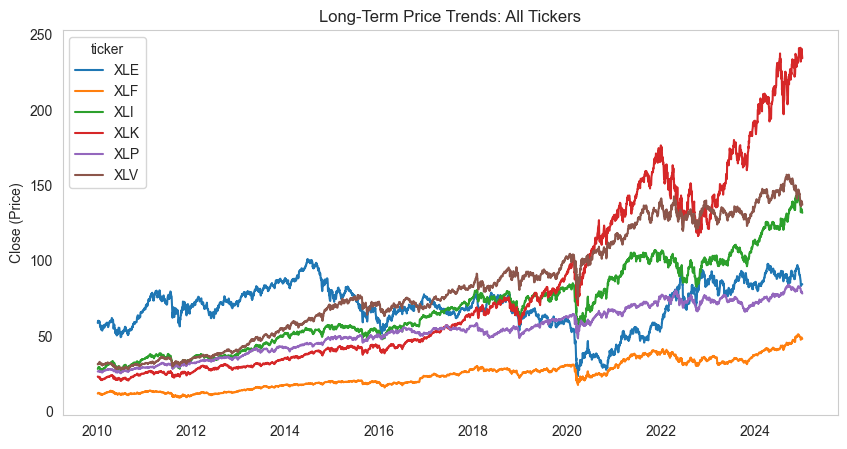

In [6]:
# Illustrate the nonstationarity of the data by showing long-term trends for all tickers

sns.lineplot(data=data, x='date', y='close', hue='ticker')
plt.title('Long-Term Price Trends: All Tickers')
plt.xlabel('')
plt.ylabel('Close (Price)')
plt.grid(False);

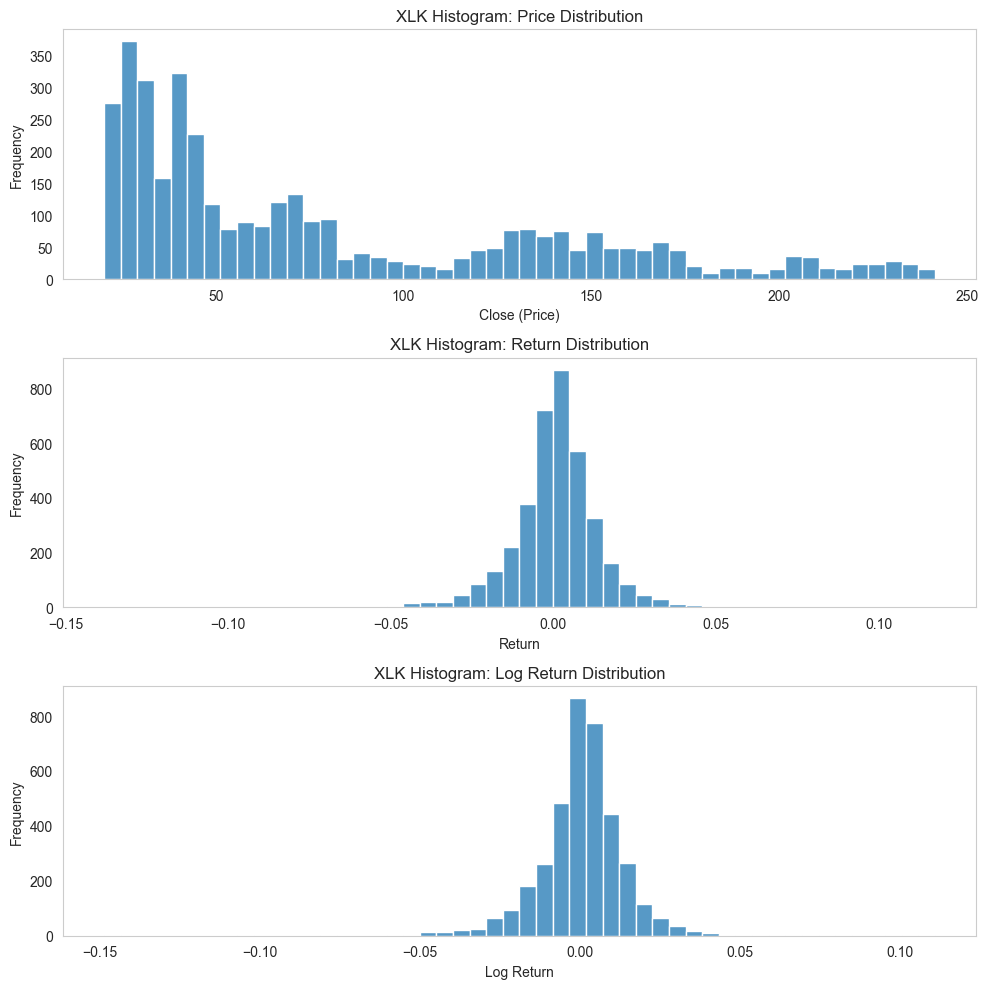

In [7]:
# Zoom in on XLK as an example to show the skewed distribution of raw prices vs. the normal distribution of returns and log returns
# Note the distribution of log returns is very similar to pure returns, but with the benefit of additivity

xlk = data.copy()[data['ticker'] == 'XLK']

fig, axes = plt.subplots(3, 1, figsize=(10, 10))

# Histogram of Price Distribution
sns.histplot(data=xlk, x='close', bins=50, ax=axes[0])
axes[0].set_title('XLK Histogram: Price Distribution')
axes[0].set_xlabel('Close (Price)')
axes[0].set_ylabel('Frequency')
axes[0].grid(False)

# Histogram of Return Distribution
xlk['return'] = xlk['close'].pct_change()
sns.histplot(data=xlk, x='return', bins=50, ax=axes[1])
axes[1].set_title('XLK Histogram: Return Distribution')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Frequency')
axes[1].grid(False)

# Histogram of Log Return Distribution
xlk['log_return'] = np.log(xlk['close'] / xlk['close'].shift(1))
sns.histplot(data=xlk, x='log_return', bins=50, ax=axes[2])
axes[2].set_title('XLK Histogram: Log Return Distribution')
axes[2].set_xlabel('Log Return')
axes[2].set_ylabel('Frequency')
axes[2].grid(False)

plt.tight_layout()
plt.show()


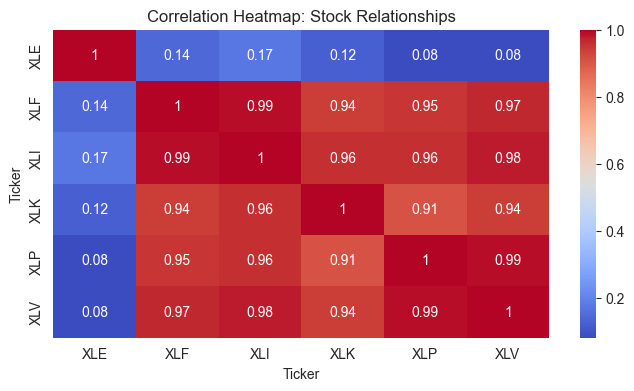

In [8]:
# Show the correlations across stocks to illustrate multicollinearity

close_by_ticker = data.pivot(index='date', columns='ticker', values='close')

plt.figure(figsize=(8, 4))
sns.heatmap(close_by_ticker.corr().round(2), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap: Stock Relationships')
plt.xlabel('Ticker')
plt.ylabel('Ticker')
plt.grid(False);


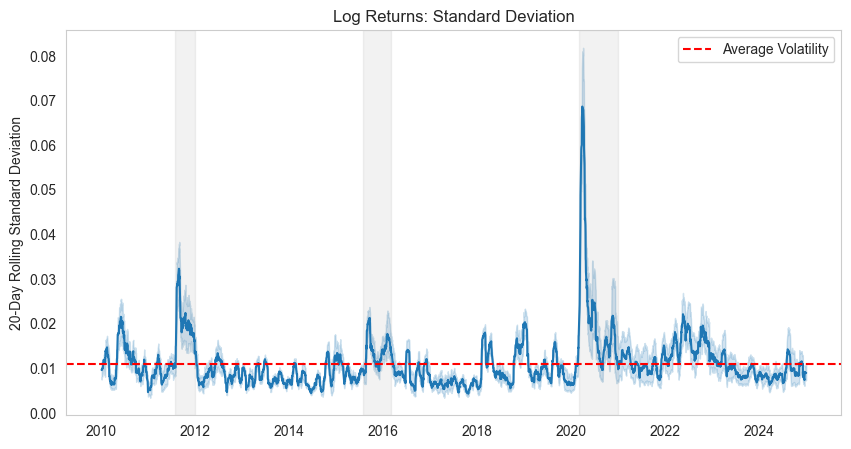

In [9]:
# Create the log returns
data = data.copy()
data['log_return'] = np.log(data['close'] / data['close'].shift(1))

# Hide the first day of data
data = data[data['date'] > data['date'].min()]

# Calculate the rolling standard deviation
data['rolling_std'] = data['log_return'].rolling(window=20).std()

# Plot the rolling standard deviation to show the volatility clustering as an example of non-linearity
sns.lineplot(data=data, x='date', y='rolling_std')
plt.axhline(data['rolling_std'].mean(), color='red', linestyle='--', label='Average Volatility')
plt.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-01-01'), color='grey', alpha=0.1)
plt.axvspan(pd.Timestamp('2011-08-01'), pd.Timestamp('2012-01-01'), color='grey', alpha=0.1)
plt.axvspan(pd.Timestamp('2015-08-01'), pd.Timestamp('2016-03-01'), color='grey', alpha=0.1)
plt.title('Log Returns: Standard Deviation')
plt.xlabel('')
plt.ylabel('20-Day Rolling Standard Deviation')
plt.grid(False)
plt.legend();


#### Exploratory Analysis Summary

In our exploratory analysis we have demonstrated a few features relevant to building machine learning models:

- Non-stationarity 
- Non-linearity
- Multicollinearity

These features (among others) are why financial time-series data is described as having a low signal:noise ratio. This places an upper limit on how accurate our predictive models can be, and it frames the overall machine learning task. 

- We use log returns to guard against non-stationarity.
- Regularisation helps tackle multicollinearity. 
- Tree-based models can handle non-linearity better. 

### Model Selection

Our model training process follows the typical steps: establish a baseline, compare a range of linear and ensemble models, engineer new features and select the best mix, and optimise the hyperparameters.

Two deep learning model architectures which specialise in sequential data have shown strong performance on financial data - Long Short-Term Memory (LSTM) and Transformers - but were excluded due to the time constraints and the additional training complexity. 

Financial time-series data analysis is plagued with data leakage, lookahead bias, model over-fitting and more. [(Advances in Financial Machine Learning, (De Prado, 2018))](https://agorism.dev/book/finance/ml/Marcos%20Lopez%20de%20Prado%20-%20Advances%20in%20Financial%20Machine%20Learning-Wiley%20%282018%29.pdf) To guard against this we need to use a more sophisticated and robust harness to handle the model training and evaluation in a leakage-safe way than common machine learning pipelines.

Here is a brief overview of two the two custom python modules providing this functionality:

- **student.py** handles the logic for engineering new features, fitting the model, optimising the hyperparameters and making predictions. 
- **mltester.py** handles the logic for building the target next-_H_-day cumulative log return $y_t = \log(C_{t+H}/C_t)$, computing the evaluation metrics and implementing the leakage-safe expanding window evaluation.

In [ ]:
# Import the robust harness for model training and evaluation
from student_experimentation import Student
from mltester import (
    read_store, price_frame_from_store, 
    forward_log_return, compute_metrics
)

# Update walk_forward_predict method in mltester.py to accept the config (e.g. model type, hyperparameters, feature set) 
# along with the model class for more experimentation
def walk_forward_predict(
    ModelClass,
    prices: pd.DataFrame,
    *,
    horizon: int = 1,
    step: int = 5,
    config: dict = None,
):
    """
    Leakage-safe expanding-window evaluation that works with model class + config.
    
    - At each refit point, fit on ALL data strictly before the first test day
      in the block; target is next-H-day cumulative log return.
    - Predict for the next `step` test days; keep only those test dates.

    Returns y_true, y_pred (both indexed by date, named 'y_true'/'y_pred').
    """
    if "Close" not in prices.columns:
        raise ValueError("prices must contain a 'Close' column")

    # Build full target once
    y_full = forward_log_return(prices["Close"], horizon=horizon)
    y_full.name = "y_true"
    test_dates = y_full.dropna().index

    preds = []
    for i in range(0, len(test_dates), step):
        block = test_dates[i : i + step]
        first_test = block[0]

        X_train = prices.loc[: first_test - pd.Timedelta(days=1)]
        y_train = y_full.loc[: first_test - pd.Timedelta(days=1)]

        # fresh model each block; accept config/random_state if available
        try:
            model = ModelClass(config=config, random_state=42)
        except TypeError:
            try:
                model = ModelClass(random_state=42)
            except TypeError:
                model = ModelClass()

        model.fit(X_train, y_train, meta={"horizon": horizon})

        X_pred = prices.loc[: block[-1]]
        y_hat = model.predict(X_pred, meta={"horizon": horizon})

        preds.append(y_hat.reindex(block).dropna())

    y_pred = pd.concat(preds) if preds else pd.Series(dtype=float, name="y_pred")
    y_pred.name = "y_pred"
    y_true = y_full.reindex(y_pred.index)
    y_true.name = "y_true"
    return y_true, y_pred

In [11]:
# Read the prices into a data store and focus on a specific ticker
prices = read_store('data/prices.csv')
prices_df = price_frame_from_store(prices, 'XLE')

# Display the new data structure for the training phase
prices_df

,Close,Open,High,Low,Adj_close,Volume
date,,,,,,
2010-01-04,58.810001,57.919998,58.810001,57.790001,35.058506,16928400
2010-01-05,59.290001,58.889999,59.410000,58.619999,35.344662,17368100
2010-01-06,60.000000,59.320000,60.180000,59.189999,35.767918,24351900
2010-01-07,59.910000,59.740002,60.009998,59.299999,35.714241,17449500
2010-01-08,60.299999,59.700001,60.349998,59.490002,35.946747,13344300
...,...,...,...,...,...,...
2024-12-23,83.930000,83.309998,84.209999,82.750000,81.909485,17222700
2024-12-24,84.639999,84.169998,84.800003,83.620003,82.602394,7512100
2024-12-26,84.570000,84.669998,84.720001,84.050003,82.534081,7693200


In [12]:
# Create baseline implementation using raw features and a default alpha value of 1
baseline_config = {
    "model_type": "ridge",
    "use_features": False,
    "use_talib": False,
    "use_selected_features": False,
    "custom_params": {"alpha": 1.0},
    "random_state": 40466218
}

# Run walk-forward evaluation for baseline model
y_true_baseline, y_pred_baseline = walk_forward_predict(
    Student, prices_df, horizon=10, step=10, config=baseline_config
)

# Compute final metrics
diracc_base, mae_base, rmse_base = compute_metrics(y_true_baseline, y_pred_baseline)

print(f"\nWalk-Forward Validation Results:")
print(f"Directional Accuracy: {diracc_base:.4f}")
print(f"MAE: {mae_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")



Walk-Forward Validation Results:
Directional Accuracy: 0.4855
MAE: 0.0391
RMSE: 0.0569


In [13]:
# Compare wider set of models against a baseline

model_types = ['ridge', 'elasticnet', 'xgboost', 'lightgbm', 'randomforest']
walk_forward_results = []

# Create default hyperparameters for each model
default_hyperparams = {
    "ridge": {"alpha": 1.0},
    "elasticnet": {"alpha": 1.0, "l1_ratio": 0.5, "max_iter": 2000},
    "xgboost": {
        "n_estimators": 100,
        "max_depth": 3,
        "learning_rate": 0.1,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    "lightgbm": {
        "n_estimators": 100,
        "max_depth": -1, # unlimited depth
        "learning_rate": 0.1,
        "num_leaves": 31,
        "subsample": 1.0,
        "colsample_bytree": 1.0
    },
    "randomforest": {
        "n_estimators": 100,
        "max_depth": 3,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "bootstrap": True,
        "max_features": "sqrt",
        "ccp_alpha": 0.0
    }
}

# Compare the performance of the models with the default hyperparameters and raw OHLCV features
for model_type in model_types:
    student_config = {
        "model_type": model_type,
        "use_features": False,
        "use_talib": False,
        "use_selected_features": False,
        "custom_params": default_hyperparams[model_type]    
    }
    y_true, y_pred = walk_forward_predict(Student, prices_df, horizon=10, step=10, config=student_config)
    diracc, mae, rmse = compute_metrics(y_true, y_pred)
    
    walk_forward_results.append({
        'model': model_type,
        'parameters': 'default',
        'feature_set': '1. Raw OHLCV',
        'diracc': diracc,
        'mae': mae, 
        'rmse': rmse
    })

model_comparison_results = pd.DataFrame(walk_forward_results)
model_comparison_results.sort_values(by='mae', ascending=True, inplace=True)
model_comparison_results



,model,parameters,feature_set,diracc,mae,rmse
1,elasticnet,default,1. Raw OHLCV,0.500133,0.038468,0.056373
0,ridge,default,1. Raw OHLCV,0.485517,0.039073,0.056901
4,randomforest,default,1. Raw OHLCV,0.502790,0.040997,0.063551
2,xgboost,default,1. Raw OHLCV,0.499601,0.043582,0.067737
3,lightgbm,default,1. Raw OHLCV,0.499867,0.046664,0.073325


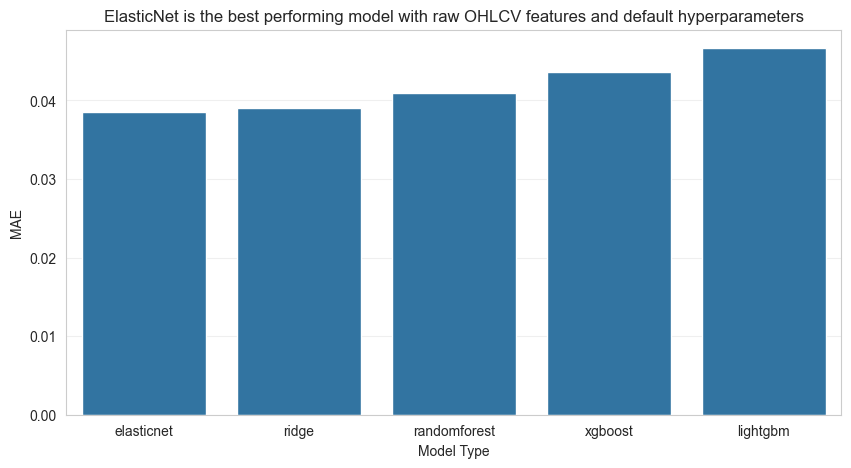

In [ ]:
'''# Plot the results of the initial model
sns.barplot(x='model', y='mae', data=model_comparison_results)
plt.title('ElasticNet is the best performing model with raw OHLCV features and default hyperparameters')
plt.xlabel('Model Type')
plt.ylabel('MAE')
plt.show()'''

### Feature Engineering 

We engineer two sets of features to compare:

- `Basic` features that represent the momentum (rolling log returns), volatility (rolling standard deviation) and smoothed trends in the market.
- The `Full` set of features expanding on on the same categories of momentum, volatility and trends like ATR, STOCH, and TEMA by moving beyond the close price to include high and low values, intraday ranges and overnight gaps, and more. It also adds an additional category of volume indicators like OBV which help confirm trends and capture cumulative buying and selling pressure.

The range of features and `TA-lib` library was selected based on the analysis in the paper [Key technical indicators for stock market prediction](https://www.sciencedirect.com/science/article/pii/S2666827025000143) (Mostafavi & Hooman, 2025).

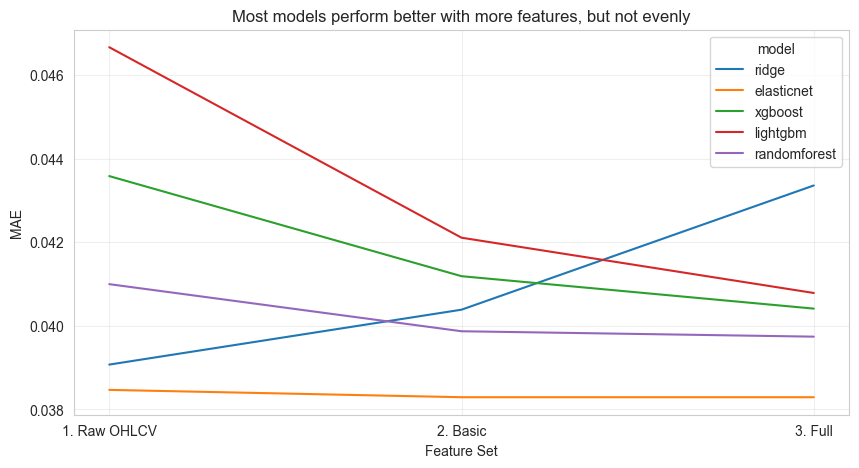

In [ ]:
'''# Compare models with different feature sets

# Using basic feature set
for model_type in model_types:
    student_config = {
        "model_type": model_type,
        "use_features": True,
        "use_talib": False,
        "use_selected_features": False,
        "custom_params": default_hyperparams[model_type]
    }
    y_true, y_pred = walk_forward_predict(Student, prices_df, horizon=10, step=10, config=student_config)
    diracc, mae, rmse = compute_metrics(y_true, y_pred)
    
    walk_forward_results.append({
        'model': model_type,
        'parameters': 'default',
        'feature_set': '2. Basic',
        'diracc': diracc,
        'mae': mae, 
        'rmse': rmse
    })

# Using full feature set with TA-lib
for model_type in model_types:
    student_config = {
        "model_type": model_type,
        "use_features": True,
        "use_talib": True,
        "use_selected_features": False,
        "custom_params": default_hyperparams[model_type]
    }
    y_true, y_pred = walk_forward_predict(Student, prices_df, horizon=10, step=10, config=student_config)
    diracc, mae, rmse = compute_metrics(y_true, y_pred)

    walk_forward_results.append({
        'model': model_type,
        'parameters': 'default',
        'feature_set': '3. Full',
        'diracc': diracc,
        'mae': mae, 
        'rmse': rmse
    })

model_comparison_results = pd.DataFrame(walk_forward_results)

# Plot the growth in performance as we add more features

sns.lineplot(x='feature_set', y='mae', hue='model', data=model_comparison_results, ci=None)
plt.title('Most models perform better with more features, but not evenly')
plt.xlabel('Feature Set')
plt.ylabel('MAE');'''


In [ ]:
'''# Show the overall table ranked by MAE

model_comparison_results.sort_values(by='mae', ascending=True, inplace=True)
model_comparison_results.reset_index(drop=True, inplace=True)
model_comparison_results'''

,model,parameters,feature_set,diracc,mae,rmse
0,elasticnet,default,2. Basic,0.482419,0.038292,0.056396
1,elasticnet,default,3. Full,0.482419,0.038292,0.056396
2,elasticnet,default,1. Raw OHLCV,0.500133,0.038468,0.056373
3,ridge,default,1. Raw OHLCV,0.485517,0.039073,0.056901
4,randomforest,default,3. Full,0.511721,0.039741,0.061635
5,randomforest,default,2. Basic,0.505860,0.039870,0.062044
6,ridge,default,2. Basic,0.466436,0.040386,0.058948
7,xgboost,default,3. Full,0.528769,0.040412,0.061532
8,lightgbm,default,3. Full,0.546084,0.040786,0.064136
9,randomforest,default,1. Raw OHLCV,0.502790,0.040997,0.063551


The results demonstrate that feature engineering can improve the performance models, but it can also harm them. This is known as the "curse of dimensionality". The gradient boosting models see significant performance gains from feature engineering, but Ridge performs significantly worse. We explore this further in the feature selection phase.

### Hyperparameter Optimisation

In the hyperparameter optimisation phase we have a two-step process:

1. Conduct extensive hyperparameter optimisation using `RandomizedSearchCV` to identify the best hyperparameter values [(Hands on Machine Learning with Scikit-Learn, Keras and Tenserflow (Géron, 2019))](http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)
2. Set the best hyperparameters as fixed values for fast training on new data

This provides the best of both worlds: highly optimised values for most hyperparameters captured in a long pre-training loop, with a much more efficient training loop at test time.

In [ ]:
import time
from mltester import forward_log_return
'''
# Define models to tune
model_types = ["ridge", "elasticnet", "xgboost", "lightgbm", "randomforest"]

# Store results
tuning_results = {}
best_params_by_model = {}

print("Starting extensive hyperparameter search...")
print("This will take significant time - each model uses 100 iterations of RandomizedSearchCV")

X = prices_df
# Use 10 day forward log returns for hyperparameter optimisation, not full walk-forward validation as the process would take too long for experimentation
y = forward_log_return(prices_df['Close'], 10) 

# Align the X and y datasets by dropping the last 10 rows from each (and excluding the nulls created in y)
X = X.iloc[:-10]
y = y.iloc[:-10]

for model_type in model_types:
    print(f"\n{'='*50}")
    print(f"Tuning {model_type.upper()} model")
    print(f"{'='*50}")
    
    start_time = time.time()
    
    # Create student in tuning mode
    model = Student(
        model_type=model_type,
        use_tuning=True,
        tuning_n_iter=100,  # Extensive search
        # Using full feature set
        use_selected_features=False,
    )
    
    # Fit with extensive search
    model.fit(X, y)
    
    # Store results
    tuning_results[model_type] = {
        'best_params': model.best_params_,
        'best_score': model.search_results_.best_score_,
        'cv_results': model.search_results_.cv_results_,
        'fit_time': time.time() - start_time
    }
    
    best_params_by_model[model_type] = model.best_params_
    
    print(f"\nBest parameters for {model_type}:")
    for param, value in model.best_params_.items():
        print(f"  {param}: {value}")
    print(f"Best CV score: {model.search_results_.best_score_:.6f}")
    print(f"Tuning time: {time.time() - start_time:.1f} seconds")'''

Starting extensive hyperparameter search...
This will take significant time - each model uses 100 iterations of RandomizedSearchCV

Tuning RIDGE model

Best parameters for ridge:
  model__alpha: 9.988481974993224
Best CV score: -0.007155
Tuning time: 0.6 seconds

Tuning ELASTICNET model

Best parameters for elasticnet:
  model__alpha: 0.015825396018008753
  model__l1_ratio: 0.3027954787655561
Best CV score: -0.003720
Tuning time: 1.3 seconds

Tuning XGBOOST model

Best parameters for xgboost:
  model__colsample_bytree: 0.6748921903327226
  model__learning_rate: 0.006714082871623601
  model__max_depth: 8
  model__n_estimators: 143
  model__subsample: 0.6954663839958295
Best CV score: -0.003905
Tuning time: 230.3 seconds

Tuning LIGHTGBM model

Best parameters for lightgbm:
  model__colsample_bytree: 0.8973017089874882
  model__learning_rate: 0.006356439926848019
  model__max_depth: 9
  model__n_estimators: 74
  model__num_leaves: 44
  model__subsample: 0.7397712091168078
Best CV score: 

In [ ]:
'''# Extract best hyperparameters for each model, convert numpy floats, and remove 'model__' prefix to allow re-use of the optimised hyperparameters
best_params_by_model = {}
for model_type in model_types:
    params = tuning_results[model_type]['best_params'].copy()
    # Convert numpy floats and remove 'model__' prefix
    clean_params = {
        k[len('model__'):] if k.startswith('model__') else k: float(v) if isinstance(v, np.floating) else v
        for k, v in params.items()
    }
    best_params_by_model[model_type] = clean_params

print("Best Hyperparameters for Each Model:\n")
best_params_by_model'''

Best Hyperparameters for Each Model:



{'ridge': {'alpha': 9.988481974993224},
 'elasticnet': {'alpha': 0.015825396018008753, 'l1_ratio': 0.3027954787655561},
 'xgboost': {'colsample_bytree': 0.6748921903327226,
  'learning_rate': 0.006714082871623601,
  'max_depth': 8,
  'n_estimators': 143,
  'subsample': 0.6954663839958295},
 'lightgbm': {'colsample_bytree': 0.8973017089874882,
  'learning_rate': 0.006356439926848019,
  'max_depth': 9,
  'n_estimators': 74,
  'num_leaves': 44,
  'subsample': 0.7397712091168078},
 'randomforest': {'bootstrap': False,
  'max_depth': 2,
  'max_features': 'sqrt',
  'min_samples_leaf': 8,
  'min_samples_split': 17,
  'n_estimators': 120}}

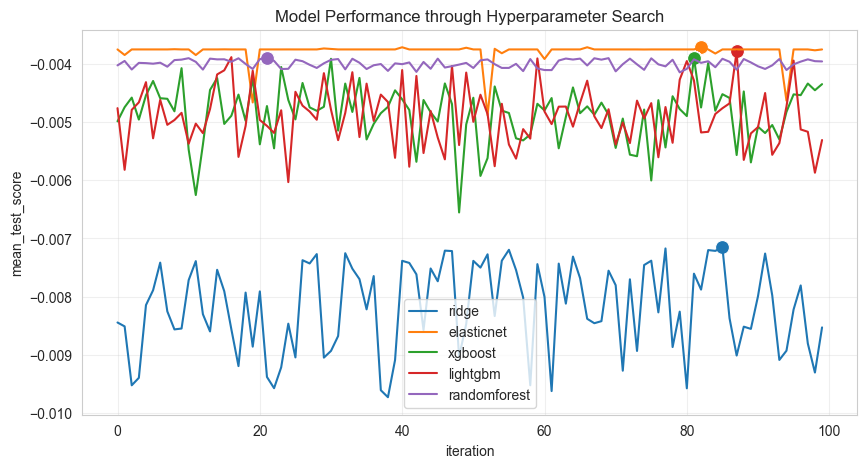

In [ ]:
'''# Plot the performance of each model through the iterations of the hyperparameter search
# Note the best hyperparameters are identified after 80 iterations for 4 of 5 models

for model_type in model_types:
    test_scores = pd.DataFrame(tuning_results[model_type]['cv_results']['mean_test_score'])
    test_scores.columns = ['mean_test_score']
    test_scores['iteration'] = test_scores.index
    test_scores['model_type'] = model_type
    test_scores['max_test_score'] = tuning_results[model_type]['cv_results']['mean_test_score'].max()
    test_scores['max_test_score_iteration'] = test_scores['mean_test_score'].idxmax()

    sns.lineplot(x='iteration', y='mean_test_score', label=model_type, data=test_scores, ci=None)
    sns.scatterplot(x='max_test_score_iteration', y='max_test_score', s=100, data=test_scores) # Highlight the best performing iteration with a circle
    plt.title(f'Model Performance through Hyperparameter Search')'''

In [ ]:
'''# Run full walk-forward validation with optimised hyperparameters for all models except Ridge - it is consistently worse
model_types = ['elasticnet', 'xgboost', 'lightgbm', 'randomforest']
walk_forward_results = []

for model_type in model_types:
    student_config = {
        "model_type": model_type,
        "use_selected_features": False
    }
    y_true, y_pred = walk_forward_predict(Student, prices_df, horizon=10, step=10, config=student_config)
    diracc, mae, rmse = compute_metrics(y_true, y_pred)
    
    walk_forward_results.append({
        'model': model_type,
        'parameters': 'optimised',
        'feature_set': 'Full',
        'diracc': diracc,
        'mae': mae, 
        'rmse': rmse
    })

# Store the results and sort by MAE
model_comparison_results = pd.DataFrame(walk_forward_results)
model_comparison_results.sort_values(by='mae', ascending=True, inplace=True)
model_comparison_results'''


,model,parameters,feature_set,diracc,mae,rmse
1,xgboost,optimised,Full,0.545285,0.038026,0.056737
2,lightgbm,optimised,Full,0.534097,0.038591,0.057812
0,elasticnet,optimised,Full,0.476825,0.038622,0.056532
3,randomforest,optimised,Full,0.497070,0.039823,0.061723


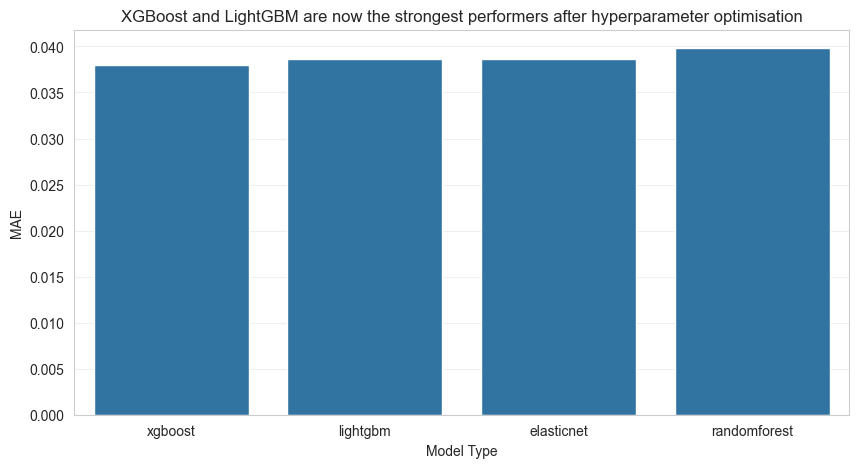

In [ ]:
'''# Plot the results
sns.barplot(x='model', y='mae', data=model_comparison_results)
plt.title('XGBoost and LightGBM are now the strongest performers after hyperparameter optimisation')
plt.xlabel('Model Type')
plt.ylabel('MAE')
plt.show()'''

`LightGBM` is selected as the final model to move forward with due to its ideal combination of model performance and efficiency: cross-validation over 100 iterations took just 34 seconds for `LightGBM` compared to 1152 seconds for `XGBoost` to achieve similar performance. This additional model efficiency is useful if we want to re-train the model every day, as we see below.

### Feature Selection

In [22]:
# Fit the final model on the optimised hyperparameters and the full feature set
final_model = Student(
    model_type='lightgbm',
    use_selected_features=False,
)

final_model.fit(prices_df, forward_log_return(prices_df['Close'], 10))

# Get the feature importances from the fitted model
fitted_model = final_model.pipe_.named_steps['model']
feature_importances = fitted_model.feature_importances_

# Get feature names (reconstruct them from the feature engineering)
feature_names = final_model._make_features(prices_df).columns.tolist()

# Create a pandas DataFrame with feature names and their importance scores
feature_importances_df = pd.DataFrame(feature_importances, index=feature_names, columns=['feature_importance'])
feature_importances_df.sort_values(by='feature_importance', ascending=False, inplace=True)
feature_importances_df['relative_importance'] = feature_importances_df['feature_importance'] / feature_importances_df['feature_importance'].sum()
feature_importances_df['cumulative_importance'] = feature_importances_df['relative_importance'].cumsum()
feature_importances_df.reset_index(inplace=True, drop=False)
feature_importances_df.rename(columns={'index': 'feature_name'}, inplace=True)

feature_importances_df


,feature_name,feature_importance,relative_importance,cumulative_importance
0,obv,139,0.076416,0.076416
1,bbands_lower,117,0.064321,0.140737
2,adx,111,0.061023,0.201759
3,vol_30,102,0.056075,0.257834
4,macdsignal,99,0.054426,0.312259
5,bbands_upper,98,0.053876,0.366135
6,sma_dist_200,93,0.051127,0.417262
7,ad,86,0.047279,0.464541
8,sma_dist_50,84,0.046179,0.510720
9,natr,77,0.042331,0.553051


In [23]:
# Test the performance of the model with a subset of the features

feature_counts = [5, 10, 20, 30, 57]
walk_forward_results = []

for feature_count in feature_counts:
    top_n_features = feature_importances_df.head(feature_count)['feature_name'].tolist()
    student_config = {
        "model_type": 'lightgbm',
        "selected_features": top_n_features
    }
    y_true, y_pred = walk_forward_predict(Student, prices_df, horizon=10, step=10, config=student_config) # larger step size for quicker training and comparisons
    diracc, mae, rmse = compute_metrics(y_true, y_pred)
    
    walk_forward_results.append({
        'feature_set': f'{feature_count} features',
        'diracc': diracc,
        'mae': mae, 
        'rmse': rmse
    })

feature_size_results = pd.DataFrame(walk_forward_results)
feature_size_results


,feature_set,diracc,mae,rmse
0,5 features,0.535162,0.038378,0.057301
1,10 features,0.529835,0.038285,0.057293
2,20 features,0.520245,0.038520,0.057816
3,30 features,0.521843,0.038586,0.057865
4,57 features,0.528769,0.038485,0.057683


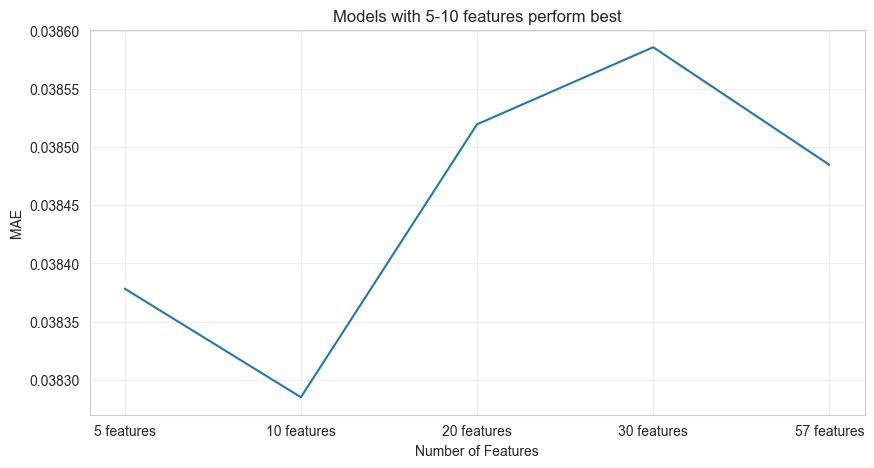

In [24]:
# Plot feature size results

sns.lineplot(x='feature_set', y='mae', data=feature_size_results, ci=None)
plt.title('Models with 5-10 features perform best')
plt.xlabel('Number of Features')
plt.ylabel('MAE')
plt.show()



In [25]:
import time

# Validate the results by testing the model on all 6 tickers with 10 features vs. the full feature set using the full walk-forward validation process

# Get available tickers from data
store = read_store('data/prices.csv')
available_tickers = store['ticker'].unique()
print(f"Available tickers: {available_tickers}")

multi_ticker_results = []

feature_counts = [10, 57]

for feature_count in feature_counts: # loop over the two feature counts

    for ticker in available_tickers: # loop over all tickers
        # Load ticker data
        ticker_df = price_frame_from_store(store, ticker)
        
        start_time = time.time()

        top_n_features = feature_importances_df.head(feature_count)['feature_name'].tolist() # get the top n features based on the feature count

        student_config = {
            "model_type": 'lightgbm',
            "use_selected_features": True,
            "selected_features": top_n_features
        }

        y_true, y_pred = walk_forward_predict(
            Student, ticker_df, horizon=10, step=10, config=student_config
        )
        
        fit_time = time.time() - start_time
        diracc, mae, rmse = compute_metrics(y_true, y_pred)
        
        multi_ticker_results.append({
            'ticker': ticker,
            'model': 'lightgbm',
            '# of features': feature_count,
            'diracc': diracc,
            'mae': mae,
            'rmse': rmse,
            'time': fit_time,
            'predictions': len(y_pred),
            'data_points': ticker_df.shape[0]
        })

# Display multi-ticker results
full_feature_comparison = pd.DataFrame(multi_ticker_results)
full_feature_comparison

Available tickers: ['XLE' 'XLF' 'XLI' 'XLK' 'XLP' 'XLV']


,ticker,model,# of features,diracc,mae,rmse,time,predictions,data_points
0,XLE,lightgbm,10,0.529835,0.038285,0.057293,15.416900,3754,3773
1,XLF,lightgbm,10,0.504795,0.029437,0.041405,14.532762,3754,3773
2,XLI,lightgbm,10,0.535162,0.026380,0.037127,16.377885,3754,3773
3,XLK,lightgbm,10,0.577251,0.027706,0.036832,15.718712,3754,3773
4,XLP,lightgbm,10,0.566063,0.017564,0.024063,17.351139,3754,3773
5,XLV,lightgbm,10,0.539425,0.021616,0.029109,16.564721,3754,3773
6,XLE,lightgbm,57,0.528769,0.038485,0.057683,45.959578,3754,3773
7,XLF,lightgbm,57,0.495738,0.029681,0.041653,40.048443,3754,3773
8,XLI,lightgbm,57,0.537826,0.026440,0.037158,48.088426,3754,3773
9,XLK,lightgbm,57,0.553543,0.028166,0.037281,45.574497,3754,3773


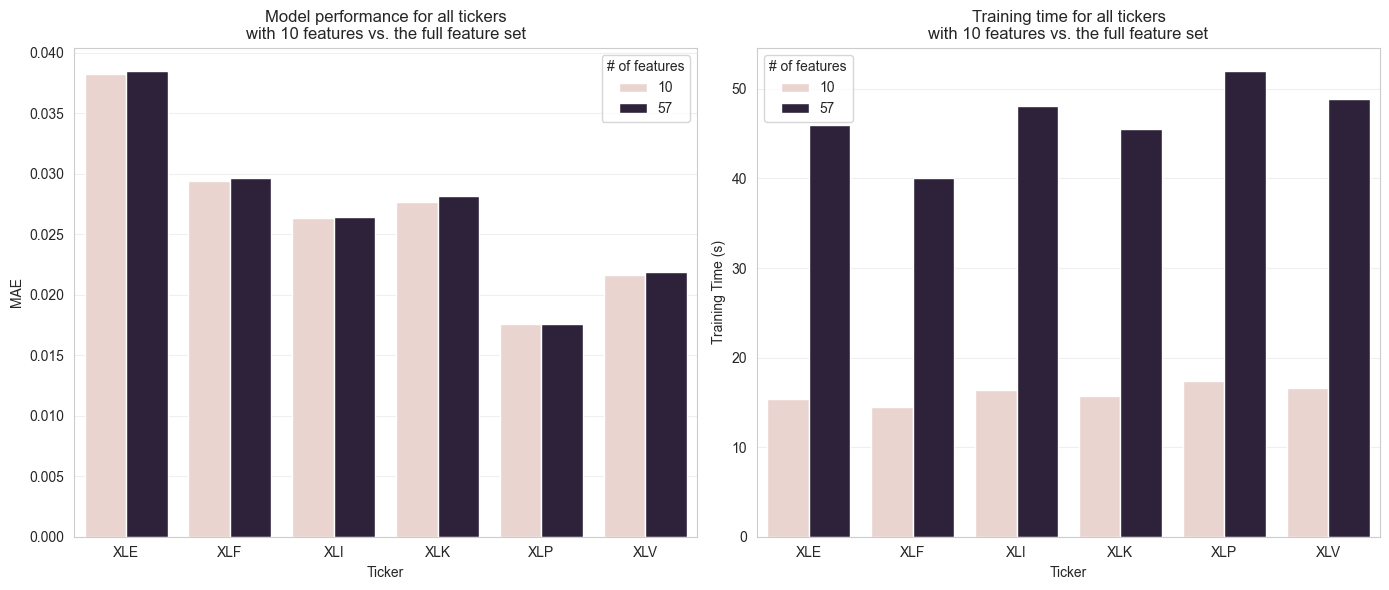

In [26]:
# Plot the model performance and training time for the two feature sets

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Model performance (MAE)
sns.barplot(ax=axes[0], x='ticker', y='mae', hue='# of features', data=full_feature_comparison)
axes[0].set_title('Model performance for all tickers\nwith 10 features vs. the full feature set')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('MAE')

# Training time
sns.barplot(ax=axes[1], x='ticker', y='time', hue='# of features', data=full_feature_comparison)
axes[1].set_title('Training time for all tickers\nwith 10 features vs. the full feature set')
axes[1].set_xlabel('Ticker')
axes[1].set_ylabel('Training Time (s)')

plt.tight_layout()
plt.show()


The model performs marginally better on each ticker with 10 features instead of 57, while the training time is over 2x as fast. 

We demonstrate the value of model efficiency in the final results below by fitting the model on a step size of 1, i.e. refitting the model every day. Directional accuracy and MAE improve significantly.

A smaller set of features also reduces the risk of over-fitting and improves model interpretability.

This defines the final step of our model selection process: we will be using the top 10 features.

In [27]:
# Display the top 10 features for reference
top_n_features = feature_importances_df.head(10)['feature_name'].tolist()

top_n_features

['obv',
 'bbands_lower',
 'adx',
 'vol_30',
 'macdsignal',
 'bbands_upper',
 'sma_dist_200',
 'ad',
 'sma_dist_50',
 'natr']

## Results

The results below demonstrate the key findings about the final model chosen:

- It performs consistently across tickers
- It performs significantly better than the baseline on every metric consistently
- It runs in a practical timeframe for each ticker, even re-fit every day (c. 5 mins)
- Performance declines in higher volatility regimes (e.g. early 2020s)

In a follow-up report we will attempt to improve overall model performance by performing clustering on the data to detect market regimes and including this as a feature in the model.

In [28]:
import time

# Get available tickers from data
store = read_store('data/prices.csv')
tickers = store['ticker'].unique()

# Wrap the full validation test in a function
def full_validation(model_type, store=store, tickers=tickers, use_selected_features=False, horizon=10, step=1, use_talib=True, use_features=True, start='2010-01-01', end='2025-01-01'):
    model_evals = []
    for ticker in tickers:
        ticker_df = price_frame_from_store(store, ticker, start=start, end=end)
        
        start_time = time.time()

        student_config = {
            "model_type": model_type,
            "tuning_mode": False,
            "use_talib": use_talib,
            "use_features": use_features,
            "use_selected_features": use_selected_features
        }
        y_true, y_pred = walk_forward_predict(
            Student, ticker_df, horizon=horizon, step=step, config=student_config
        )
        
        fit_time = time.time() - start_time
        diracc, mae, rmse = compute_metrics(y_true, y_pred)
        
        model_evals.append({
            'ticker': ticker,
            'model': model_type,
            'feature selection used': use_selected_features,
            'diracc': diracc,
            'mae': mae,
            'rmse': rmse,
            'time': fit_time
        })
        
    model_evals_df = pd.DataFrame(model_evals)

    return model_evals_df
        
# Evaluate the final model using the optimised features
final_model_full_validation = full_validation(model_type='lightgbm', use_selected_features=True)
final_model_full_validation

,ticker,model,feature selection used,diracc,mae,rmse,time
0,XLE,lightgbm,True,0.628754,0.035622,0.053143,152.577542
1,XLF,lightgbm,True,0.600319,0.027445,0.038599,145.898984
2,XLI,lightgbm,True,0.631411,0.024656,0.034825,166.757218
3,XLK,lightgbm,True,0.658517,0.025747,0.034374,164.871441
4,XLP,lightgbm,True,0.654531,0.016284,0.022454,166.934463
5,XLV,lightgbm,True,0.629551,0.020018,0.027185,159.243134


In [29]:
baseline_full_validation = full_validation(model_type='ridge', use_talib=False, use_features=False, use_selected_features=False)
baseline_full_validation

,ticker,model,feature selection used,diracc,mae,rmse,time
0,XLE,ridge,False,0.507308,0.038473,0.056073,6.896756
1,XLF,ridge,False,0.515546,0.029491,0.041071,8.306043
2,XLI,ridge,False,0.531757,0.026864,0.037395,7.034313
3,XLK,ridge,False,0.584108,0.028249,0.037509,7.117770
4,XLP,ridge,False,0.550625,0.017794,0.024241,6.992955
5,XLV,ridge,False,0.564975,0.021832,0.029285,7.078887


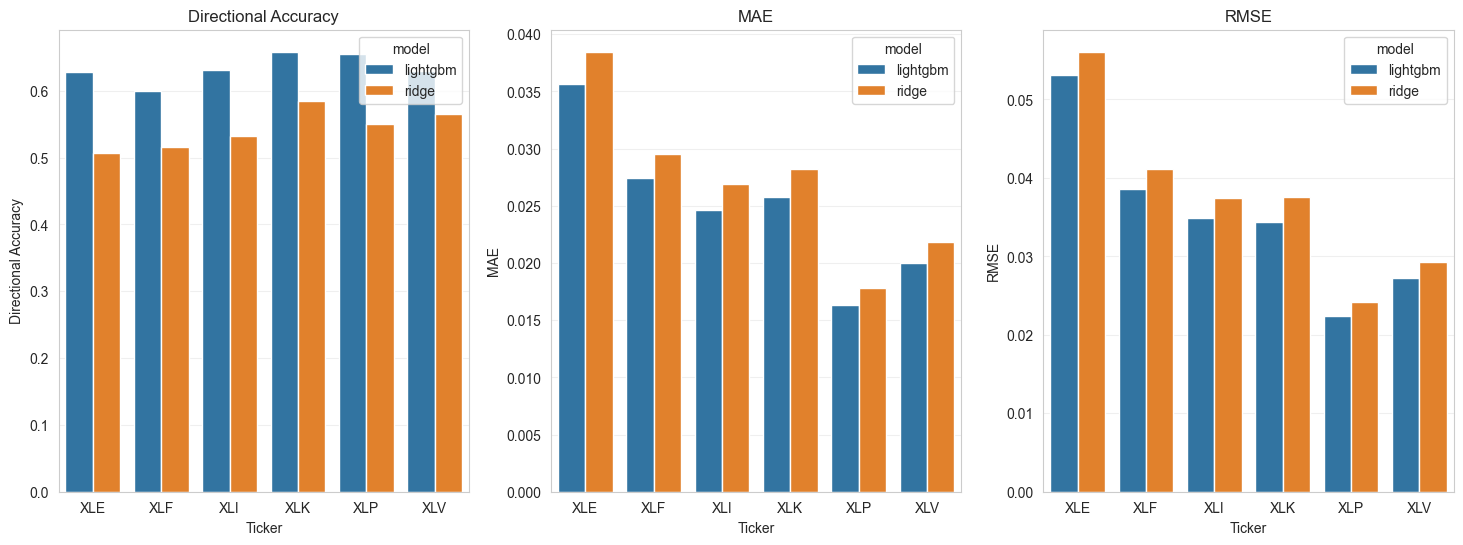

In [30]:
# Combine the results into a single dataframe
baseline_vs_final = pd.concat([final_model_full_validation, baseline_full_validation])
baseline_vs_final

# Define a function to plot the three key results for all tickers for each model
def compare_key_results(df, comparison):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Directional accuracy
    sns.barplot(ax=axes[0], x='ticker', y='diracc', hue=comparison, data=df)
    axes[0].set_title('Directional Accuracy')
    axes[0].set_xlabel('Ticker')
    axes[0].set_ylabel('Directional Accuracy');

    # MAE
    sns.barplot(ax=axes[1], x='ticker', y='mae', hue=comparison, data=df)
    axes[1].set_title('MAE')
    axes[1].set_xlabel('Ticker')
    axes[1].set_ylabel('MAE');  

    # RMSE
    sns.barplot(ax=axes[2], x='ticker', y='rmse', hue=comparison, data=df)
    axes[2].set_title('RMSE')
    axes[2].set_xlabel('Ticker')
    axes[2].set_ylabel('RMSE');

# Plot the results for the baseline vs. final model
compare_key_results(baseline_vs_final, comparison='model')



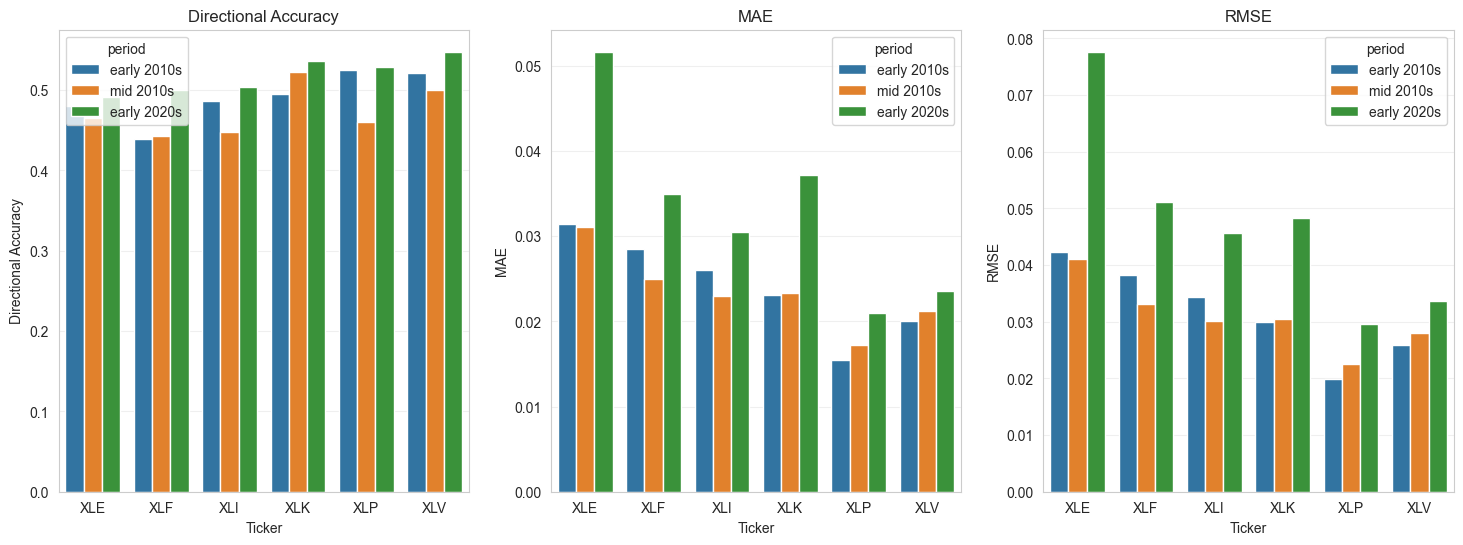

In [32]:
# Compare the performance of the model in different market regimes

early_2010s = full_validation(model_type='lightgbm', use_selected_features=True, step=10, start='2010-01-01', end='2015-01-01')
early_2010s['period'] = 'early 2010s'

mid_2010s = full_validation(model_type='lightgbm', use_selected_features=True, step=10, start='2015-01-01', end='2020-01-01')
mid_2010s['period'] = 'mid 2010s'

early_2020s = full_validation(model_type='lightgbm', use_selected_features=True, step=10, start='2020-01-01', end='2025-01-01')
early_2020s['period'] = 'early 2020s'

regime_comparison = pd.concat([early_2010s, mid_2010s, early_2020s])
compare_key_results(regime_comparison, comparison='period')

## Bibliography 

1. **De Prado, M. L.**. (2025) *Advances in Financial Machine Learning* [(link)](https://agorism.dev/book/finance/ml/Marcos%20Lopez%20de%20Prado%20-%20Advances%20in%20Financial%20Machine%20Learning-Wiley%20%282018%29.pdf)
2. **Géron, A**. (2019) *Hands on Machine Learning with Scikit-Learn, Keras and Tenserflow* [(link)](http://14.139.161.31/OddSem-0822-1122/Hands-On_Machine_Learning_with_Scikit-Learn-Keras-and-TensorFlow-2nd-Edition-Aurelien-Geron.pdf)
3. **Mostafavi, S.M. & Hooman, A. R.** (2025) *Key technical indicators for stock market prediction* [(link)](https://www.sciencedirect.com/science/article/pii/S2666827025000143)

### Notes on AI Use

AI was used to generate all of the 'ta-lib' features. Originally they were taken directly from the `ta-lib` library which is a python wrapper around a C implementation, but when testing on different systems (Mac vs. Windows) I discovered that there were system-level dependencies that prevented `ta-lib` from running correctly from a simple pip install -r requirements.txt. I used AI to recreate that library - I do not intend to take any credit for the logic or implementation of those features. They were originally identified in the paper cited above and built in an external library - I used AI just to extend that to a manual code implementation that avoids dependency conflicts and additional installation requirements.

Beyond that, AI was used regularly in two ways: as a debugger and as an auto-complete tool. When incomprehensible error messages appear, I use AI to parse and interpret the messages. The auto-complete tool recycles functions used previously in the notebook, filling in the obvious blanks - much like recycling local variables in the terminal with Tab. This just extends the references from local variables to common external libraries like pandas for common patterns: it improves efficiency while maintaining the original design and flow you have written and developed earlier in the notebook. None of the code design, architecture, plan or purpose was generated by AI. 